## Fit HMM to log energy price

In [57]:
library(devtools)
# library(ggridges)
library(dplyr)
library(tidyr)
library(ggplot2)
# library(quantmod)
# library(xts)
# library(zoo)
library(gridExtra)
# library(tibble)
library(grid)
# library(future)
# library(future.apply)
# library(DescTools)
# library(rcompanion)
# library(tidyverse)
library(parallel)

source("forecast_research/finance/markets_functions.R")
load_all("forecast_research/vendor/hmmTMB")
remotes::install_local("/project/6004619/dcs01/forecast_research/vendor/hmmTMB")
options(warn = -1)

ℹ Loading hmmTMB
Skipping install of 'hmmTMB' from a local remote, the SHA1 (1.1.0) has not changed since last install.
  Use `force = TRUE` to force installation



In [58]:
source("../finance/markets_functions.R")
load_all("../vendor/hmmTMB")
remotes::install_local("../vendor/hmmTMB")
options(warn = -1)

ERROR: Error in file(filename, "r", encoding = encoding): cannot open the connection


In [59]:
# Load processed energy data
data_path <- "energy_data/processed_energy_data.csv"
if (!file.exists(data_path)) data_path <- "energy_data/processed_energy_data"

energy_data <- read.csv(data_path)

# Quick check
head(energy_data)

,date,VWAP,VWAP_diff,log_VWAP,log_diff_VWAP,renewable_penetration,renewable_penetration_30d_avg,gas_share,gas_share_30d_avg,coal_share,coal_share_30d_avg,net_export_ratio,relative_demand,gas_price,month
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,2010-01-30,51.71312,-1.7815520,3.945712,-0.03387054,6.639171e-05,0.02137801,0.4153035,0.4148643,0.3521527,0.3400479,-0.04536398,0.6233226,4.88,1
2,2010-01-31,43.57566,-8.1374621,3.774499,-0.17121283,1.979300e-03,0.02056528,0.4198101,0.4156629,0.3463604,0.3399220,-0.03625715,0.6744772,4.88,1
3,2010-02-01,47.53579,3.9601359,3.861483,0.08698429,1.543818e-02,0.02024897,0.3898896,0.4148122,0.3633307,0.3410594,-0.04370431,1.0580356,4.68,2
4,2010-02-02,48.46112,0.9253275,3.880762,0.01927887,1.457016e-02,0.02005813,0.3956998,0.4141375,0.3623727,0.3419114,-0.03291709,1.1101773,4.68,2
5,2010-02-03,55.41471,6.9535837,4.014845,0.13408314,4.086430e-03,0.02018442,0.4188816,0.4137693,0.3576096,0.3423438,-0.02828203,1.0910957,4.68,2
6,2010-02-04,44.00796,-11.4067435,3.784371,-0.23047443,3.420153e-03,0.02023481,0.4141486,0.4136654,0.3694091,0.3428262,-0.02259798,1.0522383,4.68,2


In [60]:
end_date <- as.Date("2024-01-01")
train <- 0.7
val <- 0.15
test <- 0.15

end_idx <- which(energy_data$date == end_date)
train_idx <- 1:floor(end_idx * train)
val_idx <- (floor(end_idx * train) + 1):(floor(end_idx * (train + val)))
test_idx <- (floor(end_idx * (train + val)) + 1):end_idx

train_data <- energy_data[train_idx, ]
val_data <- energy_data[val_idx, ]
test_data <- energy_data[test_idx, ]
nrow(train_data)
nrow(val_data)
nrow(test_data)

[1] 3559

[1] 763

[1] 763

#######################
## Observation model ##
#######################
+ log_diff_VWAP ~ norm(mean, sd) 
  * mean.state1 ~ 1
  * mean.state2 ~ 1
  * mean.state3 ~ 1
  * sd.state1 ~ 1
  * sd.state2 ~ 1
  * sd.state3 ~ 1
 
> Estimated observation parameters (t = 1):
                   state 1 state 2 state 3
log_diff_VWAP.mean   0.001   0.007  -0.011
log_diff_VWAP.sd     0.112   0.278   0.992

#########################
## State process model ##
#########################
        state 1 state 2 state 3
state 1       .      ~1      ~1
state 2      ~1       .      ~1
state 3      ~1      ~1       .

> Estimated transition probabilities (t = 1):
        state 1 state 2 state 3
state 1   0.913   0.080   0.007
state 2   0.040   0.839   0.121
state 3   0.017   0.171   0.812


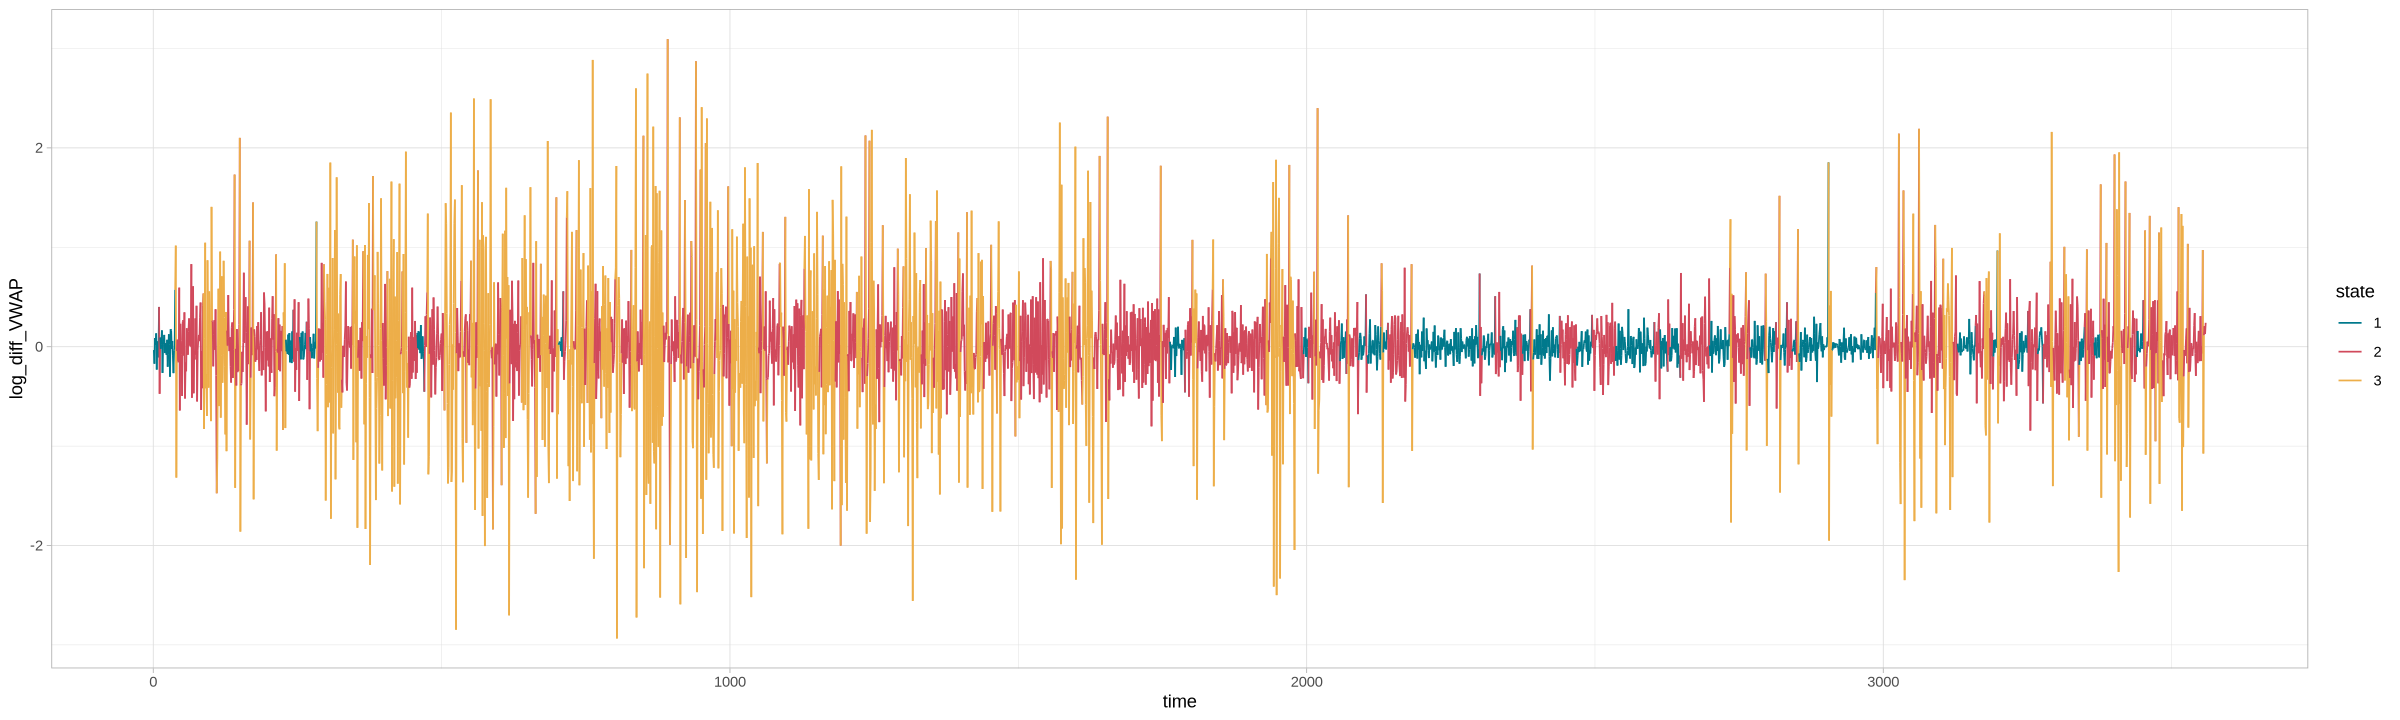

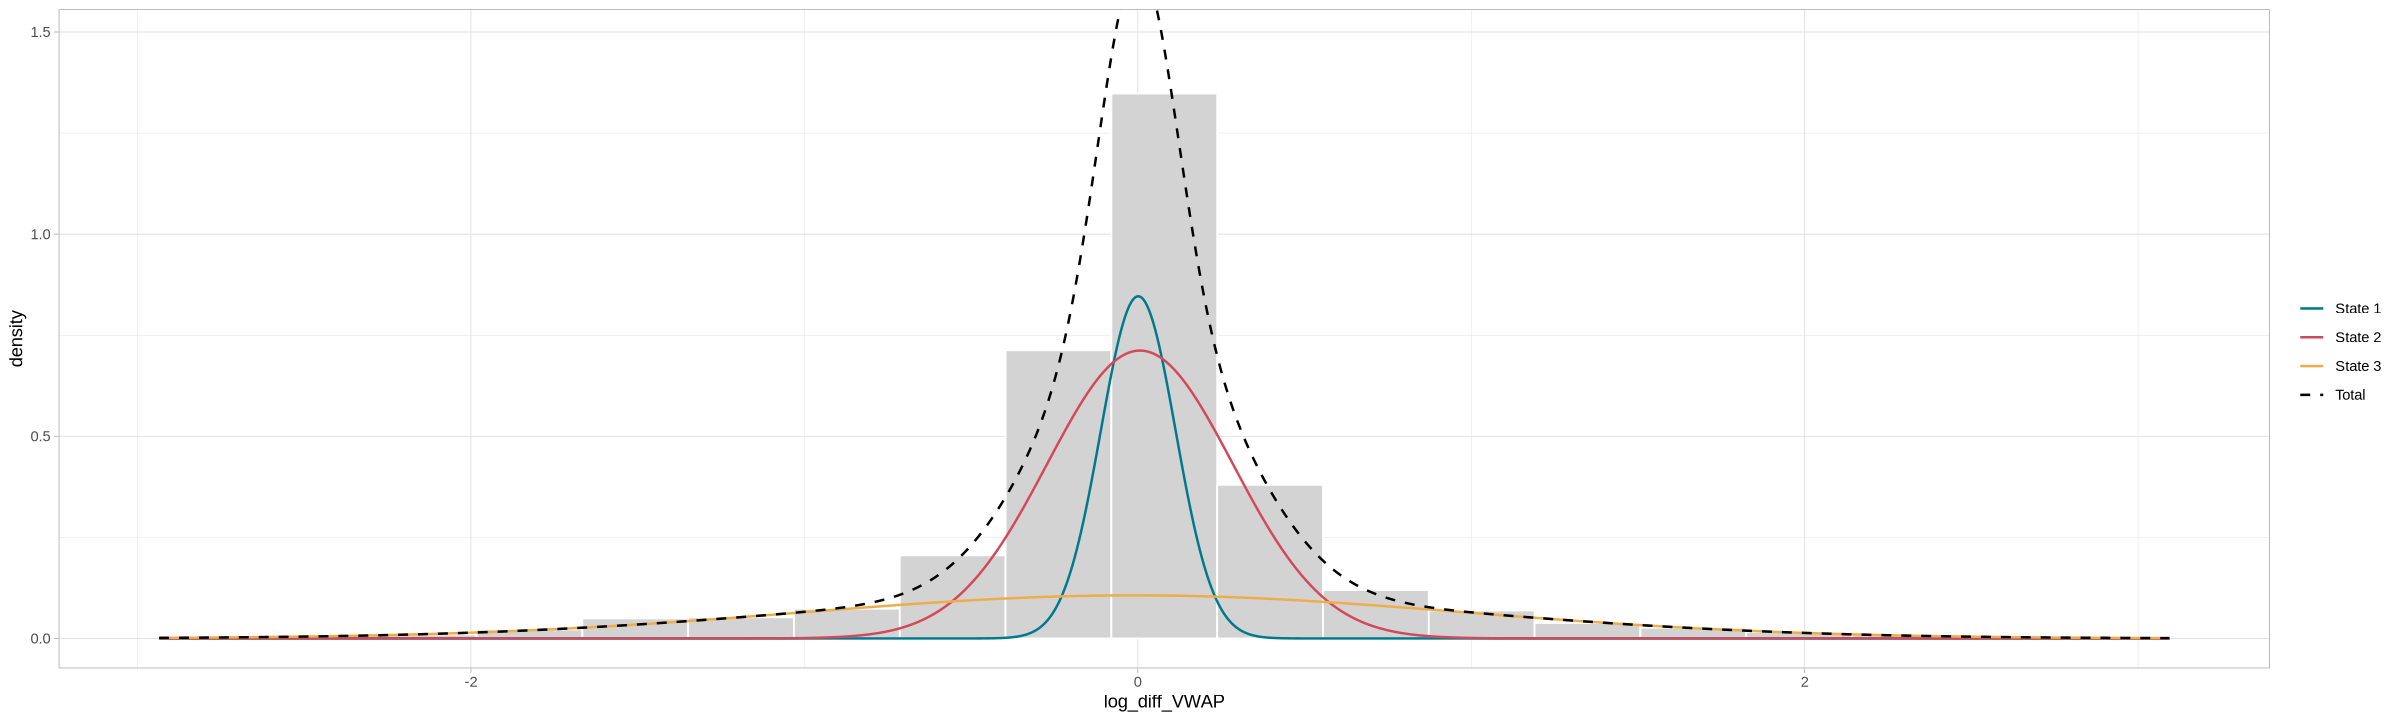

In [61]:
## Model
n_states <- 3
hid_model <- hmmTMB::MarkovChain$new(
  data = train_data,
  n_states = n_states
)
obs_model <- hmmTMB::Observation$new(
    data = train_data,
    n_states = n_states,
    dists = list(log_diff_VWAP = "norm"),
    par = list(log_diff_VWAP = list(mean = c(0.001, 0.01, -0.01), sd = c(0.1, 0.3, 1))),
  )
hmm <- hmmTMB::HMM$new(hid = hid_model, obs = obs_model)
hmm$fit(silent = TRUE)
hmm
options(repr.plot.width = 20, repr.plot.height = 6)
hmm$plot_ts("log_diff_VWAP")
hmm$plot_dist("log_diff_VWAP")


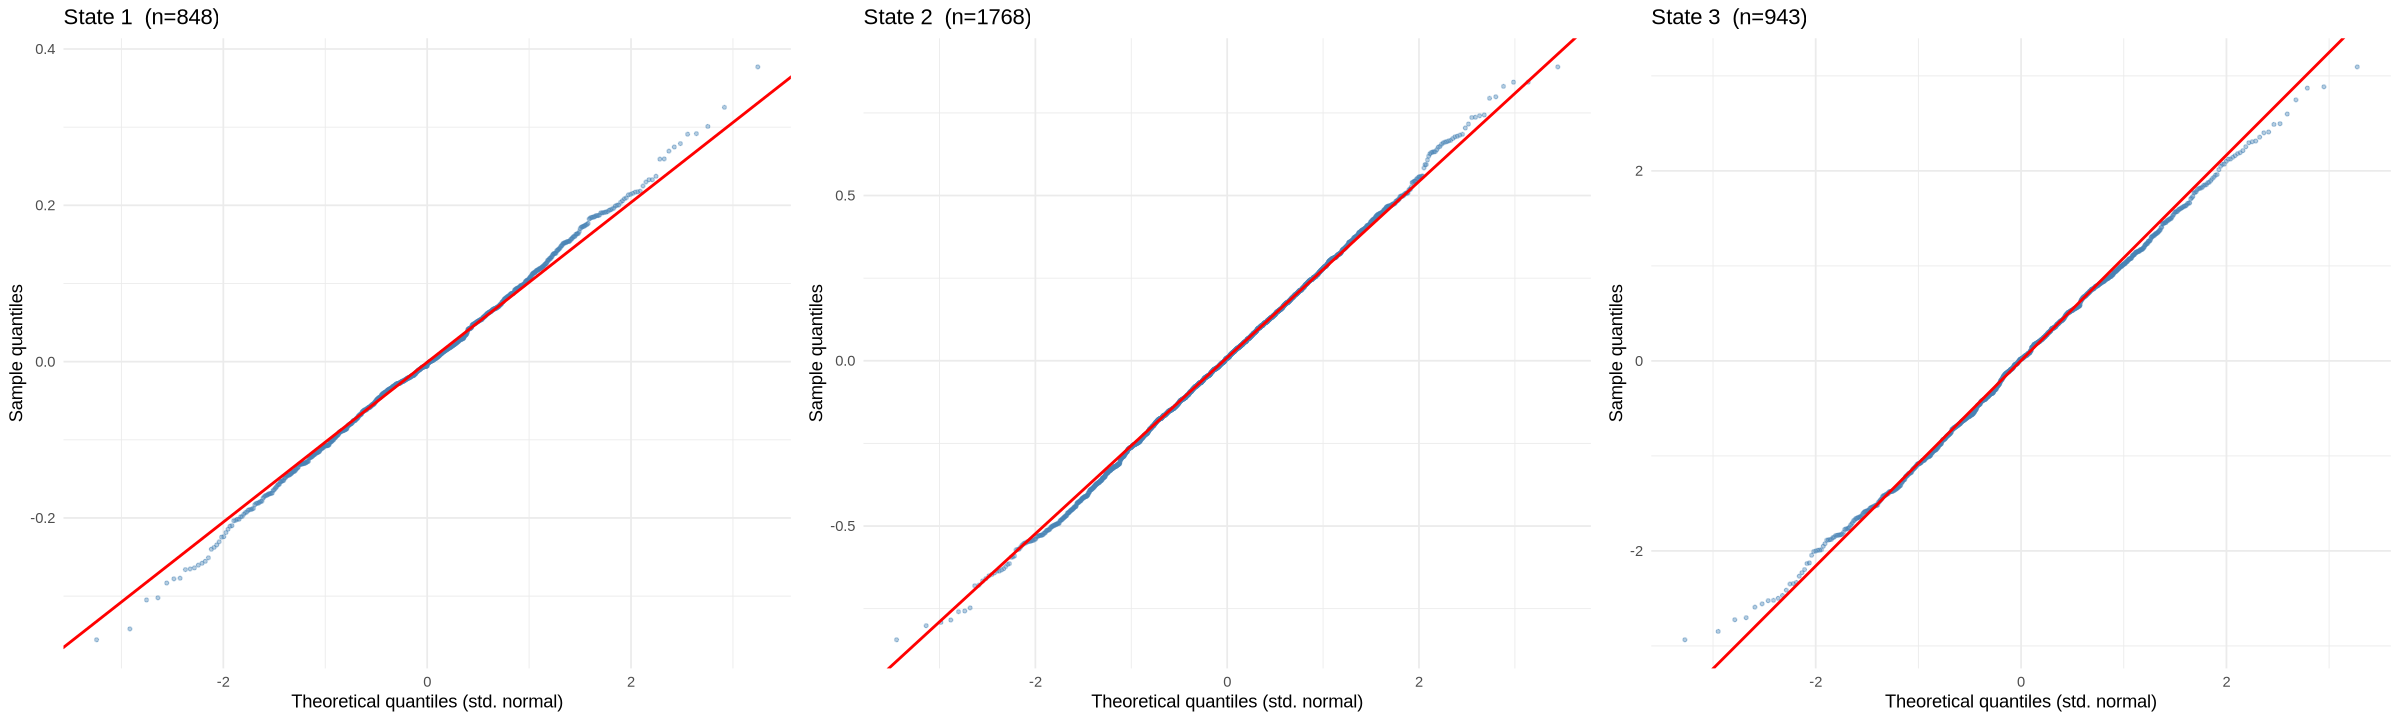

In [62]:
states_df <- data.frame(
  state = hmm$states(),
  log_diff_VWAP = train_data$log_diff_VWAP
)

n_states <- length(unique(states_df$state))

plots <- lapply(1:n_states, function(s) {
  obs <- states_df$log_diff_VWAP[states_df$state == s]
  n   <- length(obs)

  probs    <- ppoints(n)
  theor_q  <- qnorm(probs)
  sample_q <- sort(obs)

  qq_df <- data.frame(theoretical = theor_q, sample = sample_q)

  q_theory  <- qnorm(c(0.25, 0.75))
  q_sample  <- quantile(obs, c(0.25, 0.75))
  slope     <- diff(q_sample) / diff(q_theory)
  intercept <- q_sample[1] - slope * q_theory[1]

  ggplot(qq_df, aes(x = theoretical, y = sample)) +
    geom_point(alpha = 0.4, size = 0.8, color = "steelblue") +
    geom_abline(slope = slope, intercept = intercept, color = "red", linewidth = 0.8) +
    labs(
      title = sprintf("State %d  (n=%d)", s, n),
      x = "Theoretical quantiles (std. normal)",
      y = "Sample quantiles"
    ) +
    theme_minimal()
})

gridExtra::grid.arrange(grobs = plots, ncol = n_states)


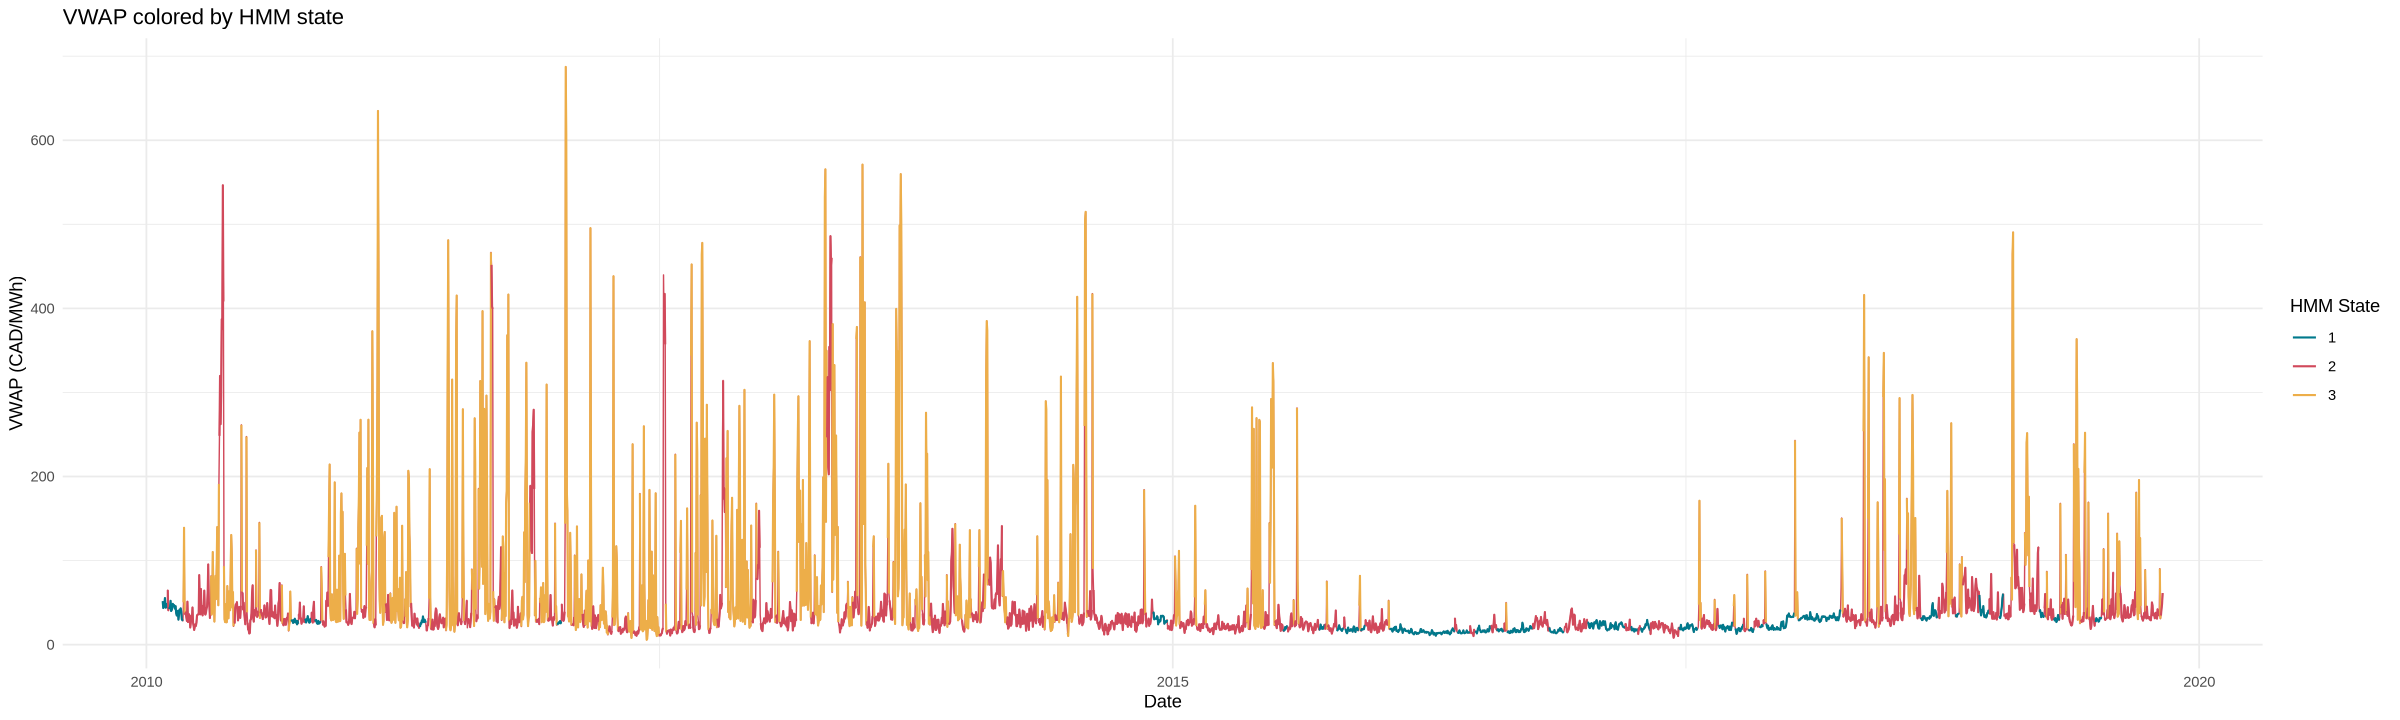

In [63]:
plot_df <- data.frame(
  date  = as.Date(train_data$date),
  VWAP  = train_data$VWAP,
  state = factor(hmm$states())
)

# Assign a unique run ID each time the state changes
plot_df$run <- cumsum(c(1, diff(as.integer(plot_df$state)) != 0))

ggplot(plot_df, aes(x = date, y = VWAP)) +
  geom_line(linewidth = 0.4, color = hmmTMB_cols[2]) +
  geom_line(aes(color = state, group = run), linewidth = 0.6) +
  scale_color_manual(values = hmmTMB_cols, name = "HMM State") +
  labs(
    title = "VWAP colored by HMM state",
    x = "Date",
    y = "VWAP (CAD/MWh)"
  ) +
  theme_minimal()


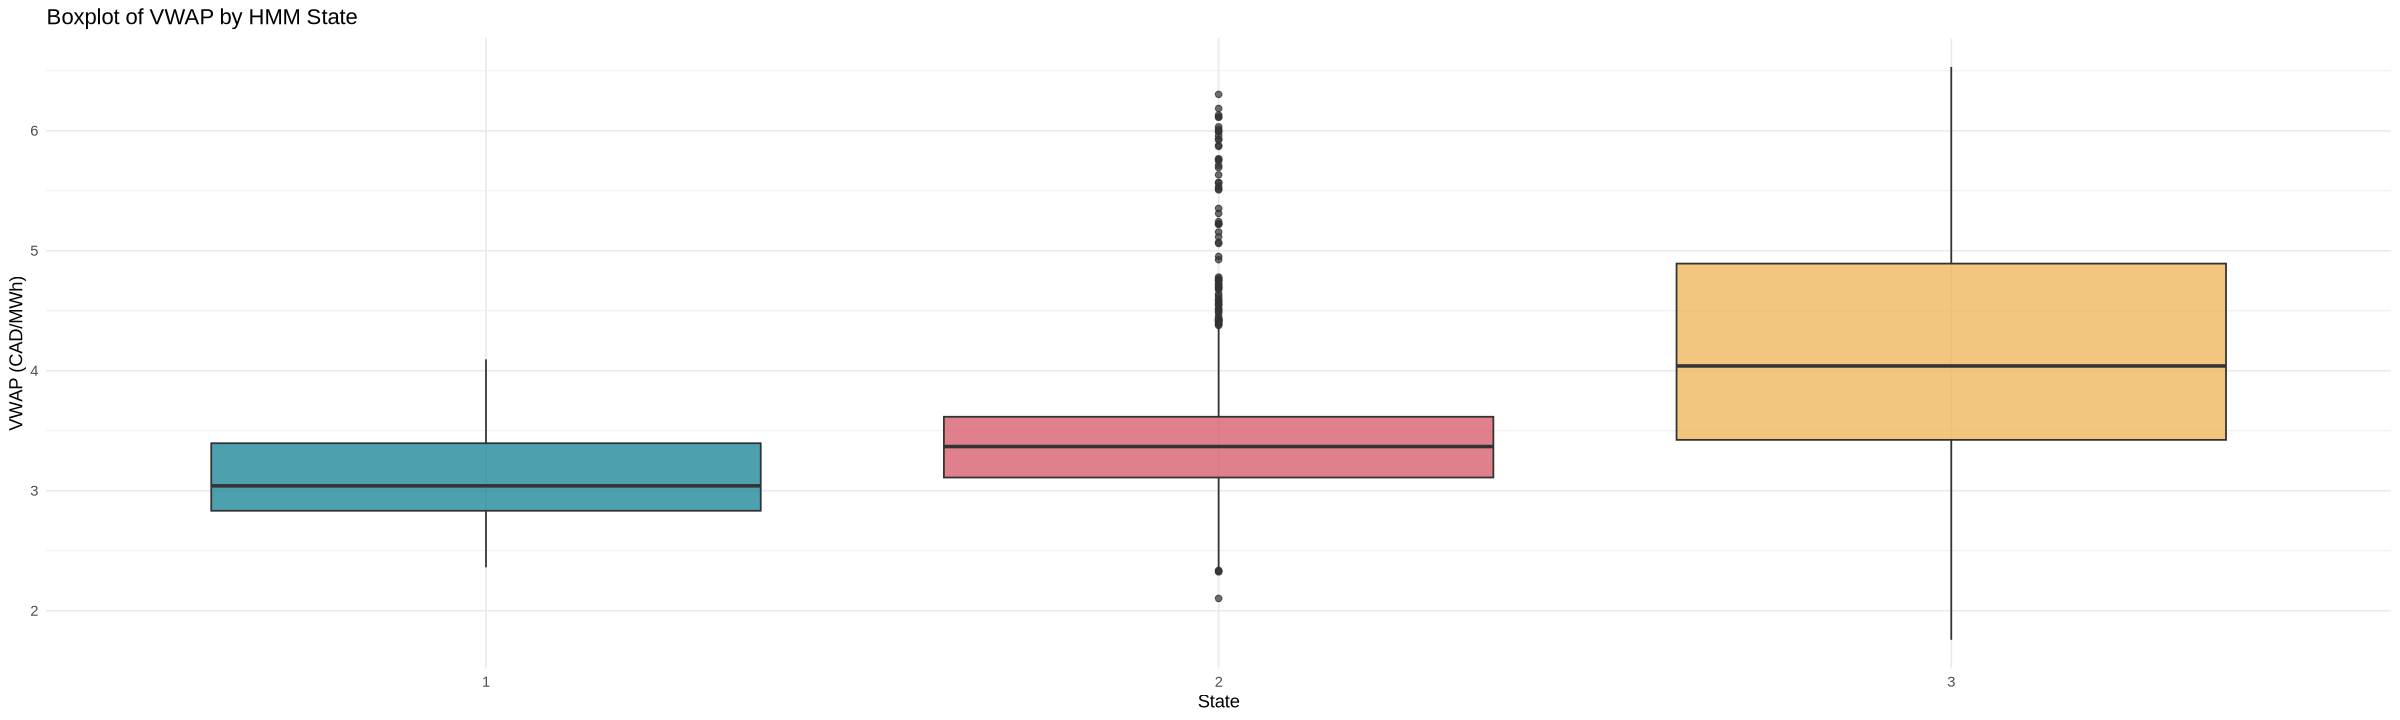

In [64]:
ggplot(plot_df, aes(x = state, y = log(VWAP))) +
  geom_boxplot(fill = hmmTMB_cols[1:3], alpha = 0.7) +
  labs(title = "Boxplot of VWAP by HMM State", x = "State", y = "VWAP (CAD/MWh)") +
  theme_minimal()

## Get remaining ground_truth states

In [65]:
n_states <- 3
hid_model <- hmmTMB::MarkovChain$new(
  data = energy_data,
  n_states = n_states
)
obs_model <- hmmTMB::Observation$new(
    data = energy_data,
    n_states = n_states,
    dists = list(log_diff_VWAP = "norm"),
    par = list(log_diff_VWAP = list(mean = c(-0.1, 0, 0.1), sd = c(1, 1, 1))),
  )
obs_model$update_par(par = obs_model$suggest_initial())
hmm_from_train <- hmmTMB::HMM$new(init = hmm, hid = hid_model, obs = obs_model)

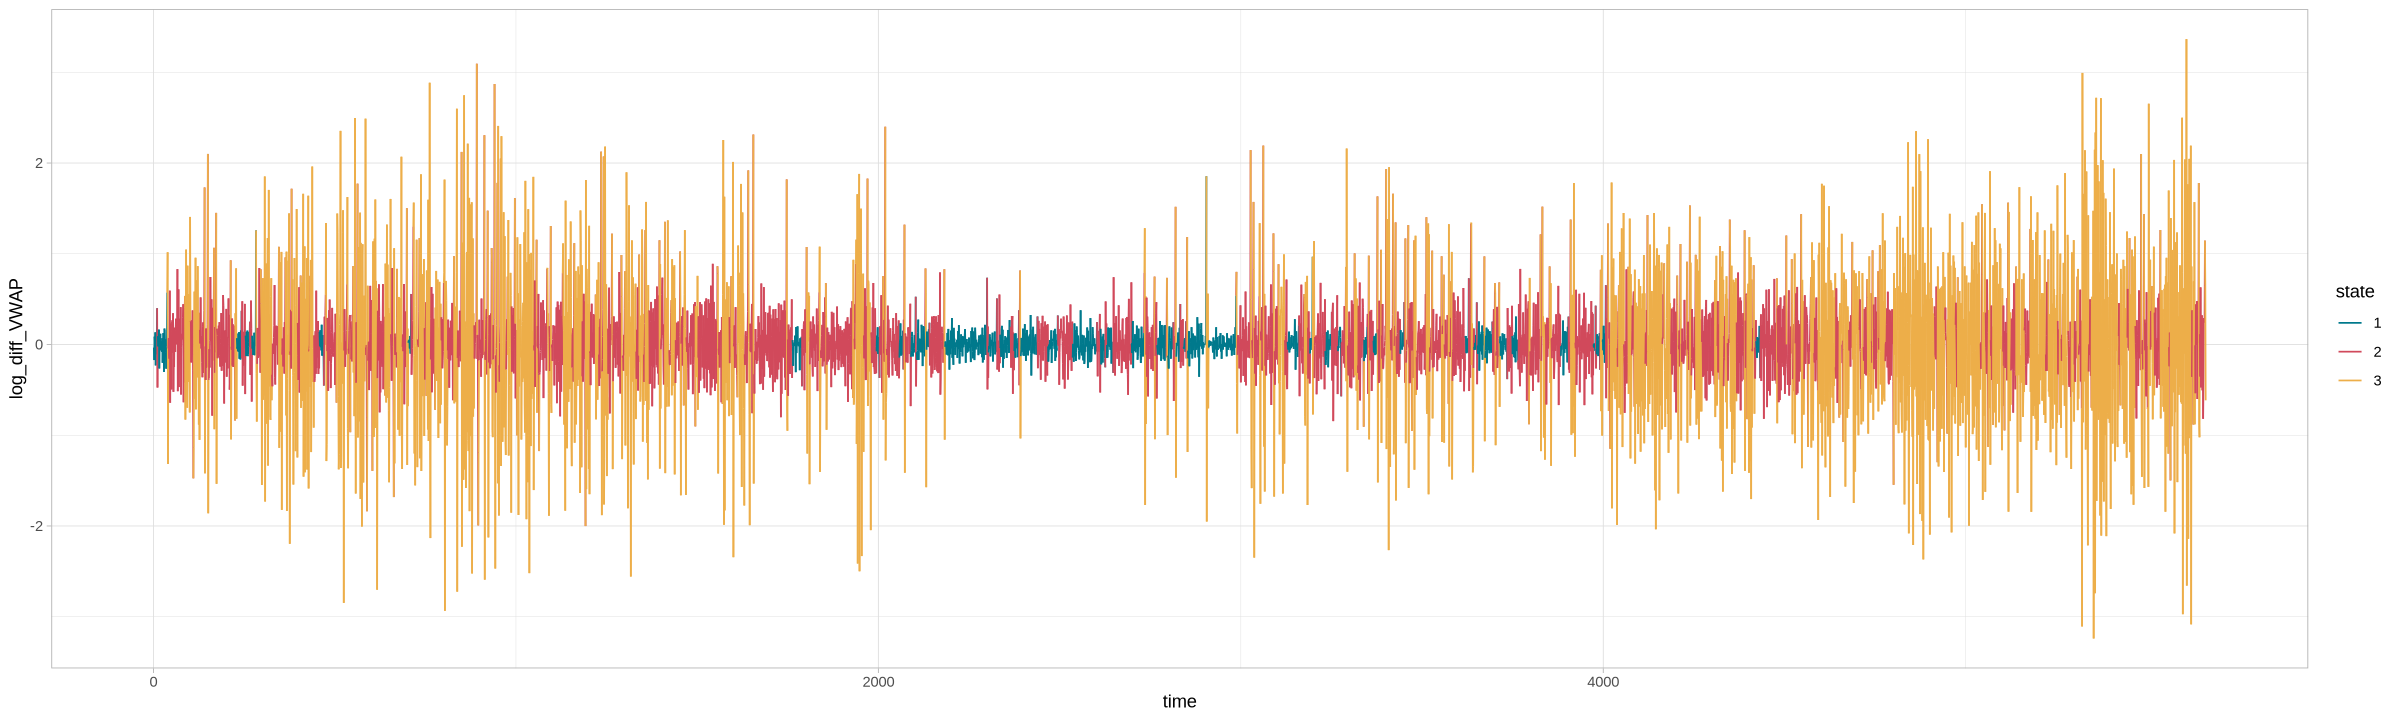

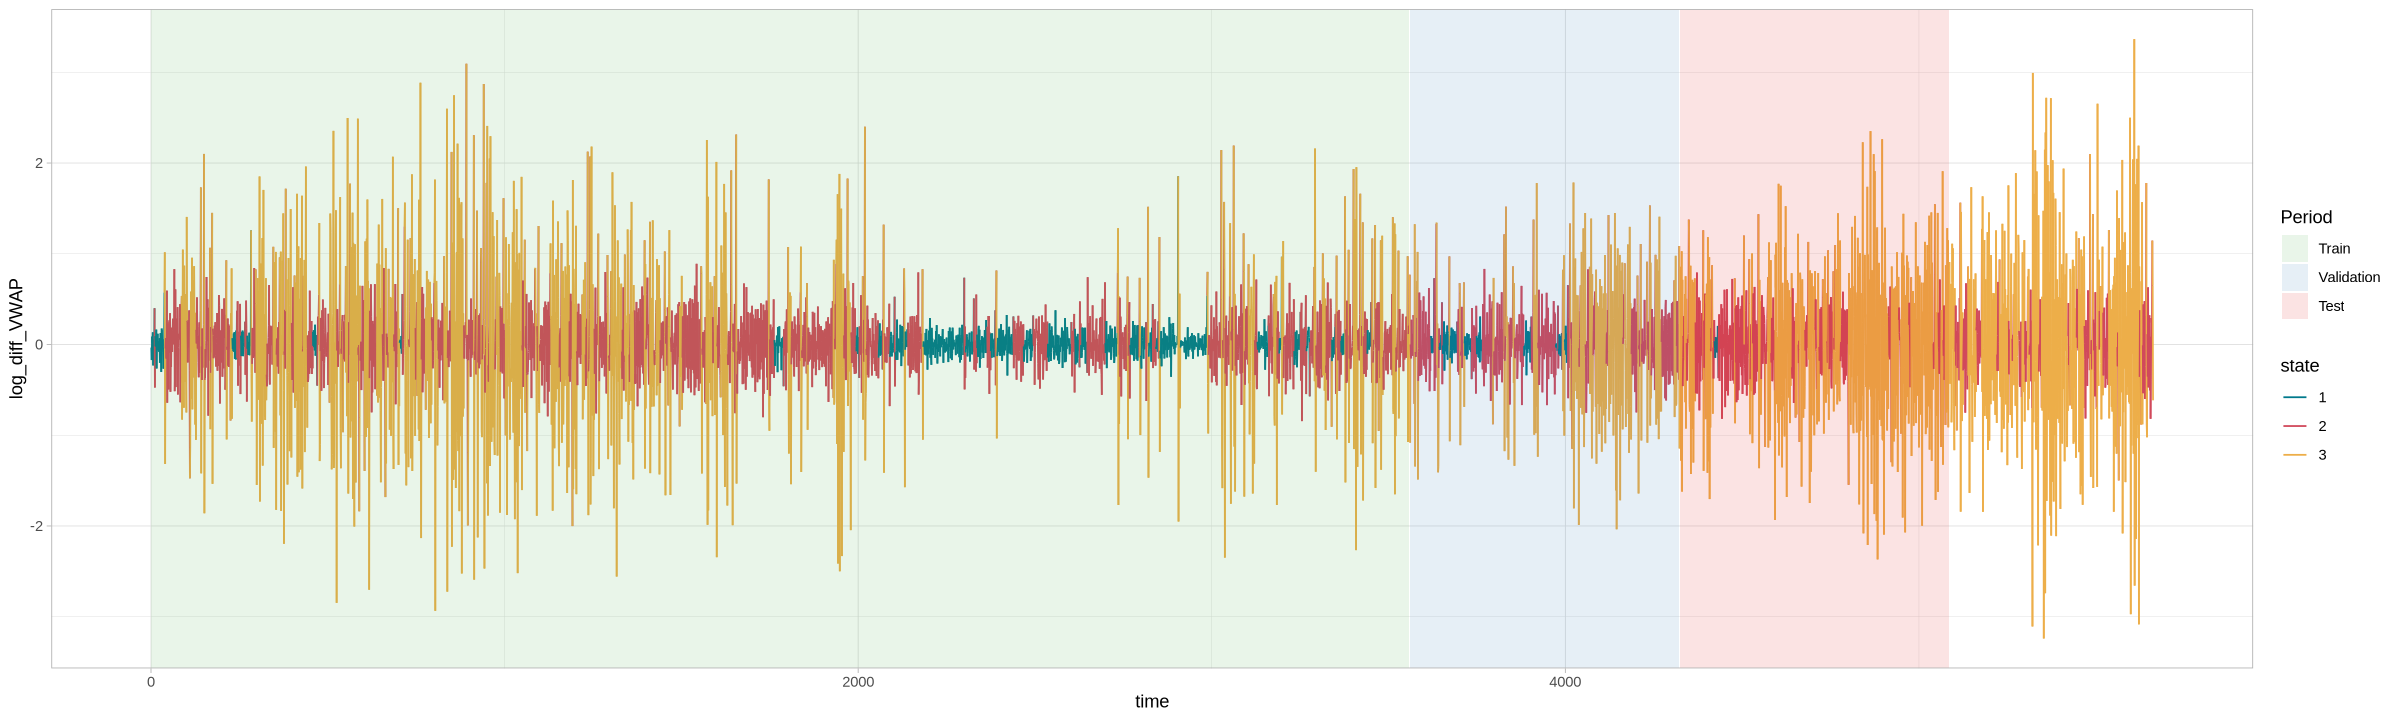

In [66]:
hmm_from_train$plot_ts("log_diff_VWAP")
period_df <- data.frame(
  xmin = c(min(train_idx), min(val_idx), min(test_idx)),
  xmax = c(max(train_idx), max(val_idx), max(test_idx)),
  period = factor(
    c("Train", "Validation", "Test"),
    levels = c("Train", "Validation", "Test")
  )
)

last_plot() +
  geom_rect(
    data = period_df,
    aes(
      xmin = xmin,
      xmax = xmax,
      ymin = -Inf,
      ymax = Inf,
      fill = period
    ),
    inherit.aes = FALSE,
    alpha = 0.12
  ) +
  scale_fill_manual(
    values = c(
      Train = "#4daf4a",
      Validation = "#377eb8",
      Test = "#e41a1c"
    )
  ) +
  labs(fill = "Period")

In [67]:
ground_truth <- hmm_from_train$state_probs()
colnames(ground_truth) <- paste0("gt_", seq_len(ncol(ground_truth)))

if (!("gt_1" %in% colnames(energy_data))) {
  energy_data <- cbind(energy_data, ground_truth)
} else {
  energy_data[, colnames(ground_truth)] <- ground_truth
}

train_data <- energy_data[train_idx, ]
val_data <- energy_data[val_idx, ]
test_data <- energy_data[test_idx, ]

colnames(train_data)

[1] "date"                          "VWAP"                         
 [3] "VWAP_diff"                     "log_VWAP"                     
 [5] "log_diff_VWAP"                 "renewable_penetration"        
 [7] "renewable_penetration_30d_avg" "gas_share"                    
 [9] "gas_share_30d_avg"             "coal_share"                   
[11] "coal_share_30d_avg"            "net_export_ratio"             
[13] "relative_demand"               "gas_price"                    
[15] "month"                         "gt_1"                         
[17] "gt_2"                          "gt_3"

In [73]:
# for in in range(buffer, end):

hmm_window <- 50
lookback <- 10
forecast_horizon <- 10
response_col <- "log_diff_VWAP"
covariate_cols <- c(
  "renewable_penetration",
  "renewable_penetration_30d_avg",
  "gas_share",
  "gas_share_30d_avg",
  "coal_share",
  "coal_share_30d_avg",
  "net_export_ratio",
  "relative_demand",
  "gas_price",
  "month"
)
observation_cols <- c(
  "gt_1",
  "gt_2",
  "gt_3"
)

create_training_set <- function(idx) {
  if (min(idx) < hmm_window) {
    idx <- hmm_window:max(idx)
  }
  num_samples <- length(idx)
  n_states <- length(observation_cols)
  features <- 1 + length(covariate_cols) + n_states

  X <- array(NA, dim = c(num_samples, lookback, features))
  Y <- array(NA, dim = c(num_samples, forecast_horizon, n_states + 1))
  Y_hat <- array(NA, dim = c(num_samples, forecast_horizon, n_states + 1))

  j <- 1
  for (i in idx) {
    current_hmm_data <- energy_data[(i-hmm_window):i, ]
    hid_model <- hmmTMB::MarkovChain$new(
      data = current_hmm_data,
      n_states = n_states
    )
    obs_model <- hmmTMB::Observation$new(
        data = current_hmm_data,
        n_states = n_states,
        dists = list(log_diff_VWAP = "norm"),
        par = list(log_diff_VWAP = list(mean = c(-0.01, 0.0, 0.01), sd = c(0.1, 0.05, 0.1)))
    )
    current_hmm <- hmmTMB::HMM$new(init = hmm, hid = hid_model, obs = obs_model)
    forecast <- hmmTMB::Forecast$new(
      hmm = current_hmm,
      n = forecast_horizon
    )
    forecasted_probs <- forecast$hidden_state_forecast()
    Y_hat[j, , ] <- cbind(
      energy_data[(i + 1):(i + forecast_horizon), 'date'],
      as.matrix(t(forecasted_probs))
    )

    current_probs <- tail(current_hmm$state_probs(), lookback)

    covariates <- cbind(
      energy_data[(i - lookback + 1):i, 'date'],
      energy_data[(i - lookback + 1):i, covariate_cols], 
      current_probs)
    Y_true <- cbind(
      energy_data[(i + 1):(i + forecast_horizon), 'date'],
      energy_data[(i + 1):(i + forecast_horizon), observation_cols]
      )

    X[j, , ] <- as.matrix(covariates)
    Y[j, , ] <- as.matrix(Y_true)
    j <- j + 1
    }
    list(X = X, Y = Y, Y_hat = Y_hat)
  }

tra <- create_training_set(train_idx)
X_train <- tra$X
Y_train <- tra$Y
Y_hat_train <- tra$Y_hat
val <- create_training_set(val_idx)
X_val <- val$X
Y_val <- val$Y
Y_hat_val <- val$Y_hat
test <- create_training_set(test_idx)
X_test <- test$X
Y_test <- test$Y
Y_hat_test <- test$Y_hat

In [76]:
feature_names <- c(
  'date',
  covariate_cols,
  paste0("state_prob_", seq_len(length(observation_cols)))
)
response_names <- c(
  'date',
  paste0("gt_", seq_len(length(observation_cols)))
)

dimnames(X_train)[[3]] <- feature_names
dimnames(Y_train)[[3]] <- response_names
dimnames(Y_hat_train)[[3]] <- response_names
dimnames(X_val)[[3]] <- feature_names
dimnames(Y_val)[[3]] <- response_names
dimnames(Y_hat_val)[[3]] <- response_names
dimnames(X_test)[[3]] <- feature_names
dimnames(Y_test)[[3]] <- response_names
dimnames(Y_hat_test)[[3]] <- response_names

In [77]:
saveRDS(X_train, file = "energy_data/X_train.rds")
saveRDS(Y_train, file = "energy_data/Y_train.rds")
saveRDS(Y_hat_train, file = "energy_data/Y_hat_train.rds")

saveRDS(X_val, file = "energy_data/X_valid.rds")
saveRDS(Y_val, file = "energy_data/Y_valid.rds")
saveRDS(Y_hat_val, file = "energy_data/Y_hat_valid.rds")

saveRDS(X_test, file = "energy_data/X_test.rds")
saveRDS(Y_test, file = "energy_data/Y_test.rds")
saveRDS(Y_hat_test, file = "energy_data/Y_hat_test.rds")



In [78]:
tpm <- hmm_from_train$hid()$tpm()
write.csv(tpm, "energy_data/transition_matrix.csv", row.names = TRUE)

## Do some analysis between the covariates and the state

In [79]:
X_train   <- readRDS("energy_data/X_train.rds")
Y_train   <- readRDS("energy_data/Y_train.rds")
Y_hat_train <- readRDS("energy_data/Y_hat_train.rds")

X_valid   <- readRDS("energy_data/X_valid.rds")
Y_valid   <- readRDS("energy_data/Y_valid.rds")
Y_hat_valid <- readRDS("energy_data/Y_hat_valid.rds")

X_test    <- readRDS("energy_data/X_test.rds")
Y_test    <- readRDS("energy_data/Y_test.rds")
Y_hat_test  <- readRDS("energy_data/Y_hat_test.rds")

In [80]:
y_true <- Y_test[, , -1]  # Exclude date column
y_true <- array(as.numeric(y_true), dim = dim(y_true))
y_hat <- Y_hat_test[, , -1]  # Exclude date column
y_hat <- array(as.numeric(y_hat), dim = dim(y_hat))

eps <- 1e-12
loss_by_horizon <- -apply(
  y_true * log(pmax(y_hat, eps)),
  MARGIN = c(1, 2),
  FUN = sum
)

stats_df <- data.frame(
  Horizon = 1:ncol(loss_by_horizon),
  mean = apply(loss_by_horizon, 2, mean, na.rm = FALSE),
  median = apply(loss_by_horizon, 2, median, na.rm = FALSE),
  P25 = apply(loss_by_horizon, 2, quantile, probs = 0.25, na.rm = FALSE),
  P75 = apply(loss_by_horizon, 2, quantile, probs = 0.75, na.rm = FALSE),
  max = apply(loss_by_horizon, 2, max, na.rm = FALSE),
  min = apply(loss_by_horizon, 2, min, na.rm = FALSE)
)

stats_df


Horizon,mean,median,P25,P75,max,min
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.7012459,0.6765856,0.4542326,0.8290087,2.604290,0.2079981
2,0.7807919,0.7430037,0.5811043,0.8875068,2.189803,0.3849441
3,0.8280476,0.7792915,0.6700831,0.9035352,2.118774,0.5322510
4,0.8604116,0.8068186,0.7240943,0.9348709,2.003613,0.6092350
5,0.8861580,0.8291344,0.7742009,0.9523535,1.940660,0.6549147
6,0.9080652,0.8575342,0.8220047,0.9660134,1.944038,0.6848361
7,0.9271961,0.8920474,0.8434788,0.9812611,1.900582,0.7075284
8,0.9433544,0.9367290,0.8524702,1.0049578,1.858393,0.7271073
9,0.9580157,0.9597765,0.8670215,1.0245141,1.798592,0.7455387


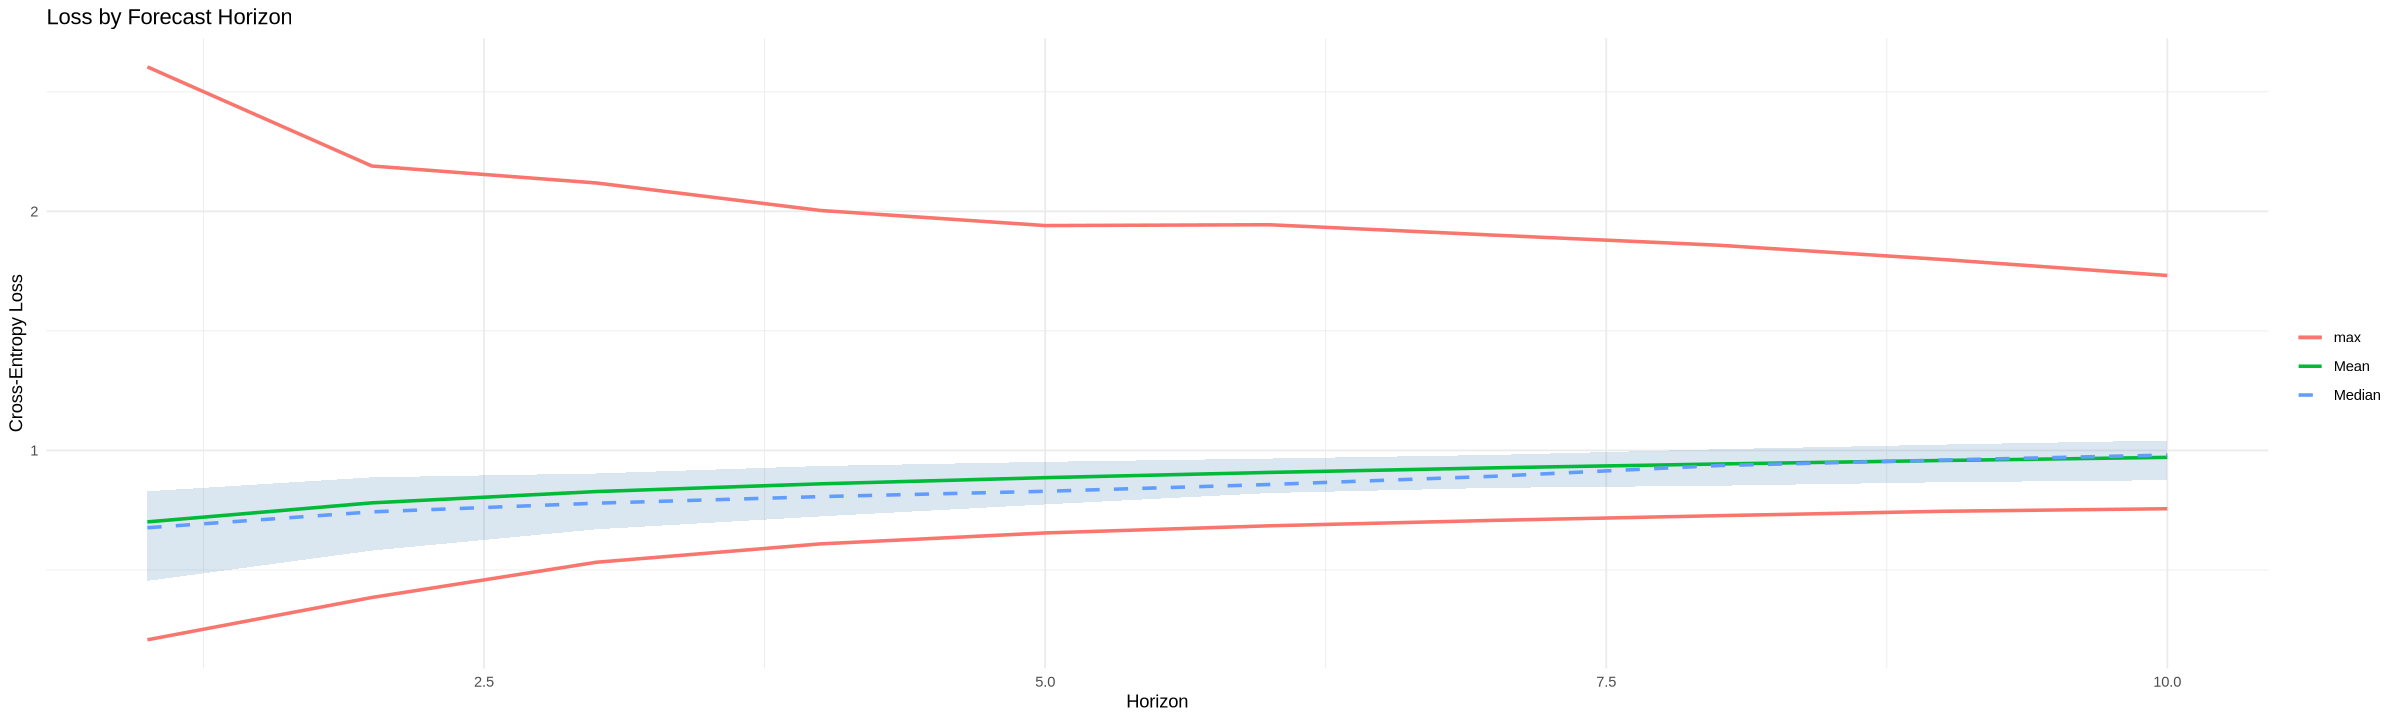

In [81]:
ggplot(stats_df, aes(x = Horizon)) +
  geom_ribbon(aes(ymin = P25, ymax = P75), fill = "steelblue", alpha = 0.2) +
  geom_line(aes(y = max, color = "max"), linewidth = 1) +
  geom_line(aes(y = mean, color = "Mean"), linewidth = 1) +
  geom_line(aes(y = median, color = "Median"), linewidth = 1, linetype = "dashed") +
  labs(
    title = "Loss by Forecast Horizon",
    y = "Cross-Entropy Loss",
    color = ""
  ) +
  geom_line(aes(y = min, color = "max"), linewidth = 1) +
  theme_minimal()

In [83]:
tbl <- table(states = hmm$states(), month = train_data$month)
chisq.test(tbl)



	Pearson's Chi-squared test

data:  tbl
X-squared = 211.84, df = 22, p-value < 2.2e-16


In [84]:
chi2 <- chisq.test(tbl)$statistic
n    <- sum(tbl)
k    <- min(nrow(tbl), ncol(tbl))
cramers_v <- sqrt(chi2 / (n * (k - 1)))
cramers_v


X-squared 
0.1725124

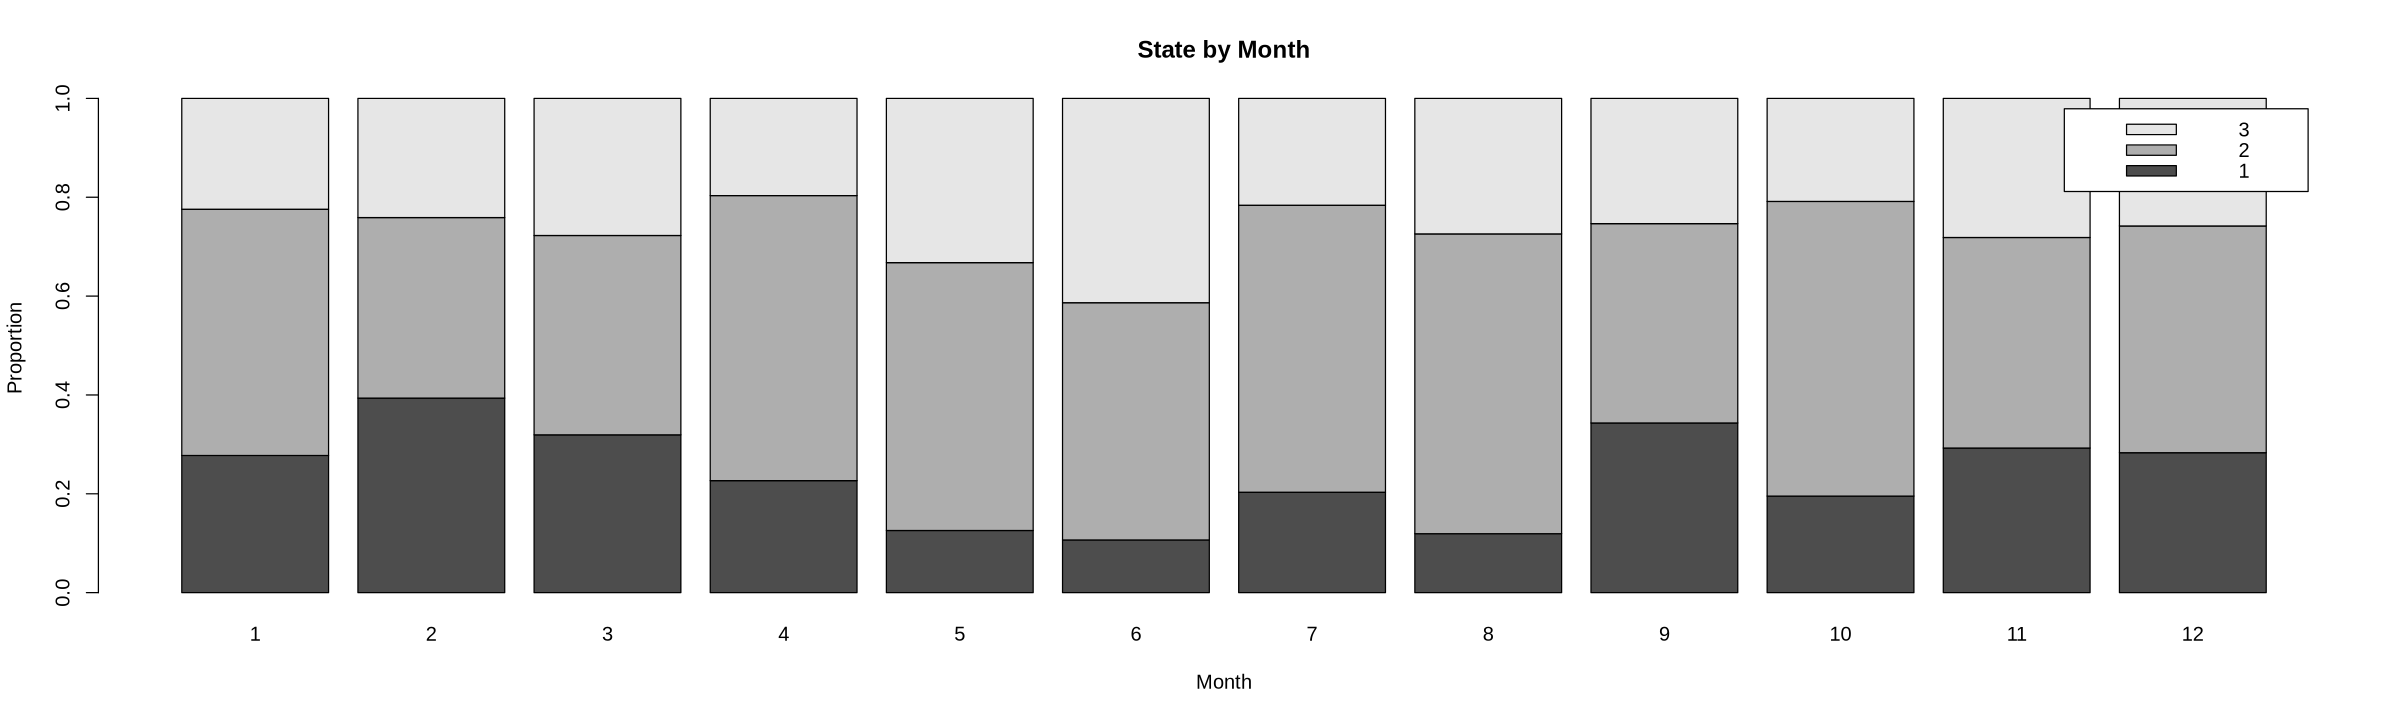

In [85]:
prop_tbl <- prop.table(tbl, margin = 2)  # proportions within each month
barplot(prop_tbl, beside = FALSE, legend = TRUE,
        xlab = "Month", ylab = "Proportion", main = "State by Month")
